In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as mpatches
import numpy as np
from scipy import optimize
import importlib
import functions_to_import_CoA as f_CoA
import solver.model
importlib.reload(solver.model)
importlib.reload(solver.model.cwrapping)
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
#clang -shared -o path/libModel_Arts_Audebert_Shi.so path/FULL_MODEL_Arts_Audebert_Shi.c -arch x86_64    --->    run in terminal

In [2]:
def default_plot(f,m,index,n_cycles,Tc,tFinal,color):
    plt.sca(f[0])
    f_CoA.plot_2(m,f[0],index,n_cycles,Tc,tFinal,color,'Time (s)','Pressure (mmHg)','RV', 'Pi','Right ventricle','-','PA_RCL', 'Pi','Pulmonary artery','--')

    plt.sca(f[1])
    f_CoA.plot_2(m,f[1],index,n_cycles,Tc,tFinal,color,'Time (s)','Blood flow (ml/s)','RV', 'Qo','Pulmonary','-','RA', 'Qo','Tricuspid','--')

    plt.sca(f[2])
    f_CoA.plot_2(m,f[2],index,n_cycles,Tc,tFinal,color,'Time (s)','Pressure (mmHg)','LV', 'Pi','Left ventricle','-','AA_RCL', 'Pi','Ascending aorta','--')

    plt.sca(f[3])
    f_CoA.plot_2(m,f[3],index,n_cycles,Tc,tFinal,color,'Time (s)','Blood flow (ml/s)','LV', 'Qo','Aortic','-','LA', 'Qo','Mitral','--')
    
    plt.sca(f[4])
    f_CoA.plot_1(m,n_cycles,Tc,tFinal,color,'Time (s)','Aortic isthmus pressure (mmHg)','AI_RCL','Pi','-')
    #f_CoA.plot_1(m,n_cycles,Tc,tFinal,color,'Time (s)','Ascending aorta pressure (mmHg)','AAA_RCL','Pi','-')
    #f_CoA.plot_1(m,n_cycles,Tc,tFinal,color,'Time (s)','Ascending aorta blood flow (ml/s)','AA_RCL','Qo','-')

    plt.sca(f[5])
    f_CoA.plot_1(m,n_cycles,Tc,tFinal,color,'Time (s)','Aortic isthmus blood flow (ml/s)','AI_RCL','Qo','-')
    #f_CoA.plot_1(m,n_cycles,Tc,tFinal,color,'Time (s)','Sarcomeres Ls','LV','Ls','-')

    plt.sca(f[6])
    f_CoA.plot_1(m,n_cycles,Tc,tFinal,color,'Time (s)','Ductus arteriosus pressure (mmHg)','Bif_PAin_LUNG1out_DA2out','Pi','-')
    #f_CoA.plot_1(m,n_cycles,Tc,tFinal,color,'Time (s)','LV contractility','LV','C','-')
    #f_CoA.plot_1(m,n_cycles,Tc,tFinal,color,'Time (s)','Ascending aortic arch (ml/s)','AAA_RCL','Qo','-')

    plt.sca(f[7])
    f_CoA.plot_1(m,n_cycles,Tc,tFinal,color,'Time (s)','Ductus arteriosus blood flow (ml/s)','Bif_PAin_LUNG1out_DA2out','Qo2','-')
    #f_CoA.plot_1(m,n_cycles,Tc,tFinal,color,'Time (s)','Descending aortic arch (ml/s)','DAA_RCL','Qo','-')

    plt.sca(f[8])
    #f_CoA.plot_1(m,n_cycles,Tc,tFinal,color,'Time (s)','Aortic isthmus pressure (mmHg)','AI_RCL','Pi','-')
    f_CoA.plot_2(m,f[8],index,n_cycles,Tc,tFinal,color,'Time (s)','Pressure (mmHg)','Bif_BR1in_UB2in_SVCout','Pi1','Jugular vein','-','Bif_BR1in_UB2in_SVCout','Pi2','Subclavian vein','--')
    plt.ylim([0,5.5])
    #f_CoA.plot_1(m,n_cycles,Tc,tFinal,color,'Time (s)','RV blood volume (ml)','RV','Vcav','-')
    #f_CoA.plot_1(m,n_cycles,Tc,tFinal,color,'Time (s)','LA blood volume (ml)','LA','Vcav','-')
    #f_CoA.plot_1(m,n_cycles,Tc,tFinal,color,'Time (s)','Thoracic aorta blood flow (ml/s)','AO1_RC','Qo','-')

    plt.sca(f[9])
    #f_CoA.plot_1(m,n_cycles,Tc,tFinal,color,'Time (s)','Aortic isthmus blood flow (ml/s)','AI_RCL','Qo','-')
    f_CoA.plot_2(m,f[9],index,n_cycles,Tc,tFinal,color,'Time (s)','Blood flow (ml/s)','Bif_BRR1in_BRL2in_BRout','Qo','Jugular vein','-','Bif_UBR1in_UBL2in_UBout','Qo','Subclavian vein','--')
    plt.ylim([0,5.5])
    #f_CoA.plot_1(m,n_cycles,Tc,tFinal,color,'Time (s)','LV blood volume (ml)','LV','Vcav','-')
    #f_CoA.plot_1(m,n_cycles,Tc,tFinal,color,'Time (s)','BCT blood flow (ml/s)','BrachT_RCL','Qo','-')

    plt.sca(f[10])
    f_CoA.plot_2(m,f[10],index,n_cycles,Tc,tFinal,color,'Time (s)','Pressure (mmHg)','PLAC_RC','Pi','Umbilical artery','-','Bif_UVin_DV1out_HE2out','Pi','Umbilical vein','--')
    #f_CoA.plot_1(m,n_cycles,Tc,tFinal,color,'Time (s)','LV sarcomere (um)','LV','Ls','-')
    #f_CoA.plot_1(m,n_cycles,Tc,tFinal,color,'Time (s)','LV volume (ml)','LV','Vcav','-')
    #f_CoA.plot_1(m,n_cycles,Tc,tFinal,color,'Time (s)','LA volume (ml)','LA','Vcav','--')
    #f_CoA.plot_2(m,f[10],index,n_cycles,Tc,tFinal,color,'Time (s)','Pressure (mmHg)','PA_RCL','Pi','Pulmonary artery','-','AO1_RC','Pi','Thoracic aorta','--')
    #f_CoA.plot_1(m,n_cycles,Tc,tFinal,color,'Time (s)','LA sarcomeres','LA','Ls','-')
    #f_CoA.plot_2(m,f[10],index,n_cycles,Tc,tFinal,color,'Time (s)','Pressure (mmHg)','Bif_BR1in_UB2in_SVCout','Pi1','Jugular vein','-','Bif_BR1in_UB2in_SVCout','Pi2','Subclavian vein','--')

    plt.sca(f[11])
    f_CoA.plot_2(m,f[11],index,n_cycles,Tc,tFinal,color,'Time (s)','Blood flow (ml/s)','Bif_AOin_LEG1out_UA2out','Qo2','Umbilical artery','-','UV_RCL','Qo','Umbilical vein','--')
    #f_CoA.plot_1(m,n_cycles,Tc,tFinal,color,'Time (s)','RV volume (ml)','RV','Vcav','-')
    #f_CoA.plot_1(m,n_cycles,Tc,tFinal,color,'Time (s)','RA volume (ml)','RA','Vcav','--')
    #f_CoA.plot_1(m,n_cycles,Tc,tFinal,color,'Time (s)','RV sarcomere (um)','RV','Ls','-')
    #f_CoA.plot_1(m,n_cycles,Tc,tFinal,color,'Time (s)','LV sarcomeres','LV','Ls','-')
    #f_CoA.plot_2(m,f[11],index,n_cycles,Tc,tFinal,color,'Time (s)','Blood flow (ml/s)','Bif_BRR1in_BRL2in_BRout','Qo','Jugular vein','-','Bif_UBR1in_UBL2in_UBout','Qo','Subclavian vein','--')


In [3]:
def ventricular_disproportion_vasculature(m,degree_aovalve,degree_pvvalve,default_values):
    # Radius arch
    radius_bct = 0.19899999999999998
    radius_lsca = 0.136435
    radius_rsca = 0.136435
    radius_lcca = 0.15234000000000003
    radius_ist = 0.2329
    radius_dAoA = 0.24756422700788266
    radius_aAoA = 0.26546686273838843
    radius_aAo = 0.2984690662736599
    radius_tAo = 0.25955
    radius_duct = 0.2090187021180712
    radius_pA = 0.3415

    #print(f"degree_pvvalve = {degree_pvvalve}")
    #print(f"degree_aovalve = {degree_aovalve}")
    
    # Pulmonary artery
    degree_pa = np.sqrt(degree_pvvalve)
    #print(f"degree_pa = {degree_pa}")
    m.setConstantOrState0('Parameters', 'Rpa', default_values['Rpa']/(degree_pa**4)) 
    m.setConstantOrState0('Parameters', 'Bmpa', default_values['Bmpa']/(degree_pa**4)) 
    m.setConstantOrState0('Parameters', 'Cpa', default_values['Cpa']*(degree_pa**2))
    m.setConstantOrState0('Parameters', 'Lpa', default_values['Lpa']/(degree_pa**2)) 
    
    # Ascending aorta
    degree_aAo = np.sqrt(degree_aovalve)
    #print(f"degree_aAo = {degree_aAo}")
    m.setConstantOrState0('Parameters', 'Raa', default_values['Raa']/(degree_aAo**4)) 
    m.setConstantOrState0('Parameters', 'Caa', default_values['Caa']*(degree_aAo**2))
    m.setConstantOrState0('Parameters', 'Laa', default_values['Laa']/(degree_aAo**2)) 


In [4]:
def ductus_increase(m,degree_da,default_values):
    m.setConstantOrState0('Parameters', 'Rda', default_values['Rda']/(degree_da**4)) 
    m.setConstantOrState0('Parameters', 'Bda', default_values['Bda']/(degree_da**4))
    

In [5]:
def aortic_narrowing(m,degree_ist,default_values):
    # Radius arch
    radius_bct = 0.19899999999999998
    radius_lsca = 0.136435
    radius_rsca = 0.136435
    radius_lcca = 0.15234000000000003
    radius_ist = 0.2329
    radius_dAoA = 0.24756422700788266
    radius_aAoA = 0.26546686273838843
    radius_aAo = 0.2984690662736599
    radius_tAo = 0.25955
    radius_duct = 0.2090187021180712
    radius_pA = 0.3415
        
    # Aortic isthmus
    m.setConstantOrState0('Parameters', 'Risthm', default_values['Risthm']/(degree_ist**4))
    m.setConstantOrState0('Parameters', 'Bisthm', default_values['Bisthm']/(degree_ist**4))
    m.setConstantOrState0('Parameters', 'Cisthm', default_values['Cisthm']*(degree_ist**2))
    m.setConstantOrState0('Parameters', 'Listhm', default_values['Listhm']/(degree_ist**2))
    
    # Desdending aortic arch
    degree_dAoA = np.cbrt(((degree_ist*radius_ist)**3 + radius_lsca**3)/radius_dAoA**3)
    m.setConstantOrState0('Parameters', 'RdAoA', default_values['RdAoA']/(degree_dAoA**4))
    m.setConstantOrState0('Parameters', 'BdAoA', default_values['BdAoA']/(degree_dAoA**4))
    m.setConstantOrState0('Parameters', 'CdAoA', default_values['CdAoA']*(degree_dAoA**2))
    m.setConstantOrState0('Parameters', 'LdAoA', default_values['LdAoA']/(degree_dAoA**2)) 
    
    # Ascending aortic arch
    degree_aAoA = np.cbrt(((degree_dAoA*radius_dAoA)**3 + radius_lcca**3)/radius_aAoA**3)
    m.setConstantOrState0('Parameters', 'RaAoA', default_values['RaAoA']/(degree_aAoA**4))     
    m.setConstantOrState0('Parameters', 'CaAoA', default_values['CaAoA']*(degree_aAoA**2))
    m.setConstantOrState0('Parameters', 'LaAoA', default_values['LaAoA']/(degree_aAoA**2))   
    
    # Ascending aorta
    degree_aAo = np.cbrt(((degree_aAoA*radius_aAoA)**3 + radius_bct**3)/radius_aAo**3)
    m.setConstantOrState0('Parameters', 'Raa', default_values['Raa']/(degree_aAo**4)) 
    m.setConstantOrState0('Parameters', 'Caa', default_values['Caa']*(degree_aAo**2))
    m.setConstantOrState0('Parameters', 'Laa', default_values['Laa']/(degree_aAo**2)) 
    
    # Aortic valve
    m.setConstantOrState0('Parameters', 'Aao', default_values['Aao']*(degree_aAo**2))


In [6]:
def function_to_optimise_CSV(variable, index_da, degree_ist, targets, Ls_lv_healthy, Ls_rv_healthy, weight, default_constants, Tc, Amref_lv, Vwall_lv, Amref_rv):
    print(f"Vwall_rv = {default_constants['Vwall_rv']*variable}")
    with f_CoA.HiddenPrints():
        Vwall_rv = default_constants['Vwall_rv']*variable
        tFinal = 25*Tc
        m = solver.model.ModelSolver('FETAL_MODEL_CoA.c')
        ductus_increase(m,index_da,default_constants)
        aortic_narrowing(m,degree_ist,default_constants)
        m.setConstantOrState0('Parameters', 'Vwall_lv', Vwall_lv)
        m.setConstantOrState0('Parameters', 'Vwall_rv', Vwall_rv)
        m.setConstantOrState0('Parameters', 'Amref_lv', Amref_lv)
        m.setConstantOrState0('Parameters', 'Amref_rv', Amref_rv)   
        m.setConstantOrState0('Parameters', 'Vwall_la', default_constants['Vwall_la']*Vwall_lv/default_constants['Vwall_lv'])
        m.setConstantOrState0('Parameters', 'Vwall_ra', default_constants['Vwall_ra']*Vwall_rv/default_constants['Vwall_rv'])
        m.setConstantOrState0('Parameters', 'Amref_la', default_constants['Amref_la']*Vwall_lv**(2/3)/default_constants['Vwall_lv']**(2/3))
        m.setConstantOrState0('Parameters', 'Amref_ra', default_constants['Amref_ra']*Vwall_rv**(2/3)/default_constants['Vwall_rv']**(2/3))   
        m.setConstantOrState0('Parameters', 'Amdead_lv', default_constants['Amdead_lv']*Vwall_lv**(2/3)/default_constants['Vwall_lv']**(2/3))
        m.setConstantOrState0('Parameters', 'Amdead_rv', default_constants['Amdead_rv']*Vwall_rv**(2/3)/default_constants['Vwall_rv']**(2/3)) 
        m.setConstantOrState0('Parameters', 'Amdead_la', default_constants['Amdead_la']*Vwall_lv**(2/3)/default_constants['Vwall_lv']**(2/3))
        m.setConstantOrState0('Parameters', 'Amdead_ra', default_constants['Amdead_ra']*Vwall_rv**(2/3)/default_constants['Vwall_rv']**(2/3)) 
        m.setConstantOrState0('Parameters', 'Aao', default_constants['Aao']*Vwall_lv**(2/3)/default_constants['Vwall_lv']**(2/3))
        m.setConstantOrState0('Parameters', 'Ami', default_constants['Ami']*Vwall_lv**(2/3)/default_constants['Vwall_lv']**(2/3))
        m.setConstantOrState0('Parameters', 'Apv', default_constants['Apv']*Vwall_rv**(2/3)/default_constants['Vwall_rv']**(2/3))
        m.setConstantOrState0('Parameters', 'Atr', default_constants['Atr']*Vwall_rv**(2/3)/default_constants['Vwall_rv']**(2/3))        
        ventricular_disproportion_vasculature(m,Vwall_lv**(2/3)/default_constants['Vwall_lv']**(2/3),Vwall_rv**(2/3)/default_constants['Vwall_rv']**(2/3),default_constants)
        m.solve(tFinal = tFinal)

    idx = m.t > tFinal - Tc
    CSV = np.trapz(m.getVariable('LV', 'Qo')[idx], m.t[idx]) + np.trapz(m.getVariable('RV', 'Qo')[idx], m.t[idx])

    Ls_lv_min = np.min(m.getVariable('LV', 'Ls')[idx])
    Ls_lv_max = np.max(m.getVariable('LV', 'Ls')[idx])
    Ls_rv_min = np.min(m.getVariable('RV', 'Ls')[idx])
    Ls_rv_max = np.max(m.getVariable('RV', 'Ls')[idx])  
        
    predictions = [CSV,Ls_lv_min,Ls_lv_max,Ls_rv_min,Ls_rv_max]
    targets_2 = [targets,np.min(Ls_lv_healthy),np.max(Ls_lv_healthy),np.min(Ls_rv_healthy),np.max(Ls_rv_healthy)]

    rmse_val = f_CoA.rmse2(predictions, targets_2, [1,0.5,0.5,0.5,0.5])
    print(f"rmse_val = {rmse_val}")   
    return rmse_val

In [7]:
def function_to_optimise_thicknessLV(variable, index_da, degree_ist, targets, Ls_lv_healthy, Ls_rv_healthy, weight, default_constants, Tc, Vwall_lv, Amref_rv, Vwall_rv):
    print(f"Amref_lv = {variable}")
    with f_CoA.HiddenPrints():
        Amref_lv = variable
        tFinal = 25*Tc
        m = solver.model.ModelSolver('FETAL_MODEL_CoA.c')
        ductus_increase(m,index_da,default_constants)
        aortic_narrowing(m,degree_ist,default_constants)
        m.setConstantOrState0('Parameters', 'Vwall_lv', Vwall_lv)
        m.setConstantOrState0('Parameters', 'Vwall_rv', Vwall_rv)
        m.setConstantOrState0('Parameters', 'Amref_lv', Amref_lv)
        m.setConstantOrState0('Parameters', 'Amref_rv', Amref_rv)   
        m.setConstantOrState0('Parameters', 'Vwall_la', default_constants['Vwall_la']*Vwall_lv/default_constants['Vwall_lv'])
        m.setConstantOrState0('Parameters', 'Vwall_ra', default_constants['Vwall_ra']*Vwall_rv/default_constants['Vwall_rv'])
        m.setConstantOrState0('Parameters', 'Amref_la', default_constants['Amref_la']*Vwall_lv**(2/3)/default_constants['Vwall_lv']**(2/3))
        m.setConstantOrState0('Parameters', 'Amref_ra', default_constants['Amref_ra']*Vwall_rv**(2/3)/default_constants['Vwall_rv']**(2/3))   
        m.setConstantOrState0('Parameters', 'Amdead_lv', default_constants['Amdead_lv']*Vwall_lv**(2/3)/default_constants['Vwall_lv']**(2/3))
        m.setConstantOrState0('Parameters', 'Amdead_rv', default_constants['Amdead_rv']*Vwall_rv**(2/3)/default_constants['Vwall_rv']**(2/3)) 
        m.setConstantOrState0('Parameters', 'Amdead_la', default_constants['Amdead_la']*Vwall_lv**(2/3)/default_constants['Vwall_lv']**(2/3))
        m.setConstantOrState0('Parameters', 'Amdead_ra', default_constants['Amdead_ra']*Vwall_rv**(2/3)/default_constants['Vwall_rv']**(2/3)) 
        m.setConstantOrState0('Parameters', 'Aao', default_constants['Aao']*Vwall_lv**(2/3)/default_constants['Vwall_lv']**(2/3))
        m.setConstantOrState0('Parameters', 'Ami', default_constants['Ami']*Vwall_lv**(2/3)/default_constants['Vwall_lv']**(2/3))
        m.setConstantOrState0('Parameters', 'Apv', default_constants['Apv']*Vwall_rv**(2/3)/default_constants['Vwall_rv']**(2/3))
        m.setConstantOrState0('Parameters', 'Atr', default_constants['Atr']*Vwall_rv**(2/3)/default_constants['Vwall_rv']**(2/3))        
        ventricular_disproportion_vasculature(m,Vwall_lv**(2/3)/default_constants['Vwall_lv']**(2/3),Vwall_rv**(2/3)/default_constants['Vwall_rv']**(2/3),default_constants)
        m.solve(tFinal = tFinal)

    idx = m.t > tFinal - Tc
    Vcav_lv = np.max(m.getVariable('LV', 'Vcav')[idx])
    Vcav_Vwall_lv = Vcav_lv/Vwall_lv

    Ls_lv_min = np.min(m.getVariable('LV', 'Ls')[idx])
    Ls_lv_max = np.max(m.getVariable('LV', 'Ls')[idx])
    Ls_rv_min = np.min(m.getVariable('RV', 'Ls')[idx])
    Ls_rv_max = np.max(m.getVariable('RV', 'Ls')[idx])  
        
    predictions = [Vcav_Vwall_lv,Ls_lv_min,Ls_lv_max,Ls_rv_min,Ls_rv_max]
    targets_2 = [targets,np.min(Ls_lv_healthy),np.max(Ls_lv_healthy),np.min(Ls_rv_healthy),np.max(Ls_rv_healthy)]

    rmse_val = f_CoA.rmse2(predictions, targets_2, [1,0.5,0.5,0.5,0.5])
    print(f"rmse_val = {rmse_val}")   
    return rmse_val

In [8]:
def function_to_optimise_thicknessRV(variable, index_da, degree_ist, targets, Ls_lv_healthy, Ls_rv_healthy, weight, default_constants, Tc, Amref_lv, Vwall_lv, Vwall_rv):
    print(f"Amref_rv = {variable}")    
    with f_CoA.HiddenPrints():
        Amref_rv = variable
        tFinal = 25*Tc
        m = solver.model.ModelSolver('FETAL_MODEL_CoA.c')
        ductus_increase(m,index_da,default_constants)
        aortic_narrowing(m,degree_ist,default_constants)
        m.setConstantOrState0('Parameters', 'Vwall_lv', Vwall_lv)
        m.setConstantOrState0('Parameters', 'Vwall_rv', Vwall_rv)
        m.setConstantOrState0('Parameters', 'Amref_lv', Amref_lv)
        m.setConstantOrState0('Parameters', 'Amref_rv', Amref_rv)   
        m.setConstantOrState0('Parameters', 'Vwall_la', default_constants['Vwall_la']*Vwall_lv/default_constants['Vwall_lv'])
        m.setConstantOrState0('Parameters', 'Vwall_ra', default_constants['Vwall_ra']*Vwall_rv/default_constants['Vwall_rv'])
        m.setConstantOrState0('Parameters', 'Amref_la', default_constants['Amref_la']*Vwall_lv**(2/3)/default_constants['Vwall_lv']**(2/3))
        m.setConstantOrState0('Parameters', 'Amref_ra', default_constants['Amref_ra']*Vwall_rv**(2/3)/default_constants['Vwall_rv']**(2/3))   
        m.setConstantOrState0('Parameters', 'Amdead_lv', default_constants['Amdead_lv']*Vwall_lv**(2/3)/default_constants['Vwall_lv']**(2/3))
        m.setConstantOrState0('Parameters', 'Amdead_rv', default_constants['Amdead_rv']*Vwall_rv**(2/3)/default_constants['Vwall_rv']**(2/3)) 
        m.setConstantOrState0('Parameters', 'Amdead_la', default_constants['Amdead_la']*Vwall_lv**(2/3)/default_constants['Vwall_lv']**(2/3))
        m.setConstantOrState0('Parameters', 'Amdead_ra', default_constants['Amdead_ra']*Vwall_rv**(2/3)/default_constants['Vwall_rv']**(2/3)) 
        m.setConstantOrState0('Parameters', 'Aao', default_constants['Aao']*Vwall_lv**(2/3)/default_constants['Vwall_lv']**(2/3))
        m.setConstantOrState0('Parameters', 'Ami', default_constants['Ami']*Vwall_lv**(2/3)/default_constants['Vwall_lv']**(2/3))
        m.setConstantOrState0('Parameters', 'Apv', default_constants['Apv']*Vwall_rv**(2/3)/default_constants['Vwall_rv']**(2/3))
        m.setConstantOrState0('Parameters', 'Atr', default_constants['Atr']*Vwall_rv**(2/3)/default_constants['Vwall_rv']**(2/3))        
        ventricular_disproportion_vasculature(m,Vwall_lv**(2/3)/default_constants['Vwall_lv']**(2/3),Vwall_rv**(2/3)/default_constants['Vwall_rv']**(2/3),default_constants)
        m.solve(tFinal = tFinal)

    idx = m.t > tFinal - Tc
    Vcav_rv = np.max(m.getVariable('RV', 'Vcav')[idx])
    Vcav_Vwall_rv = Vcav_rv/Vwall_rv

    Ls_lv_min = np.min(m.getVariable('LV', 'Ls')[idx])
    Ls_lv_max = np.max(m.getVariable('LV', 'Ls')[idx])
    Ls_rv_min = np.min(m.getVariable('RV', 'Ls')[idx])
    Ls_rv_max = np.max(m.getVariable('RV', 'Ls')[idx])  
        
    predictions = [Vcav_Vwall_rv,Ls_lv_min,Ls_lv_max,Ls_rv_min,Ls_rv_max]
    targets_2 = [targets,np.min(Ls_lv_healthy),np.max(Ls_lv_healthy),np.min(Ls_rv_healthy),np.max(Ls_rv_healthy)]

    rmse_val = f_CoA.rmse2(predictions, targets_2, [1,0.5,0.5,0.5,0.5])
    print(f"rmse_val = {rmse_val}")    
    return rmse_val

running build_ext
building 'computeRates' extension
clang -Wno-unused-result -Wsign-compare -Wunreachable-code -DNDEBUG -fwrapv -O2 -Wall -fPIC -O2 -isystem /opt/anaconda3/include -arch x86_64 -I/opt/anaconda3/include -fPIC -O2 -isystem /opt/anaconda3/include -arch x86_64 -I/opt/anaconda3/lib/python3.9/site-packages/numpy/core/include -I/opt/anaconda3/include/python3.9 -c computeRates.c -o build/temp.macosx-10.9-x86_64-cpython-39/computeRates.o --std=c99


In file included from computeRates.c:773:
In file included from /opt/anaconda3/lib/python3.9/site-packages/numpy/core/include/numpy/arrayobject.h:4:
In file included from /opt/anaconda3/lib/python3.9/site-packages/numpy/core/include/numpy/ndarrayobject.h:12:
In file included from /opt/anaconda3/lib/python3.9/site-packages/numpy/core/include/numpy/ndarraytypes.h:1969:
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/include/numpy/npy_1_7_deprecated_api.h:17:2: warning: "Using deprecated NumPy API, disable it with "          "#define NPY_NO_DEPRECATED_API NPY_1_7_API_VERSION" [-W#warnings]
   17 | #warning "Using deprecated NumPy API, disable it with " \
      |  ^
1 warning generated.


clang -Wno-unused-result -Wsign-compare -Wunreachable-code -DNDEBUG -fwrapv -O2 -Wall -fPIC -O2 -isystem /opt/anaconda3/include -arch x86_64 -I/opt/anaconda3/include -fPIC -O2 -isystem /opt/anaconda3/include -arch x86_64 -I/opt/anaconda3/lib/python3.9/site-packages/numpy/core/include -I/opt/anaconda3/include/python3.9 -c model.c -o build/temp.macosx-10.9-x86_64-cpython-39/model.o --std=c99
clang -bundle -undefined dynamic_lookup -Wl,-rpath,/opt/anaconda3/lib -L/opt/anaconda3/lib -L/opt/anaconda3/lib -Wl,-rpath,/opt/anaconda3/lib -L/opt/anaconda3/lib build/temp.macosx-10.9-x86_64-cpython-39/computeRates.o build/temp.macosx-10.9-x86_64-cpython-39/model.o -o build/lib.macosx-10.9-x86_64-cpython-39/computeRates.cpython-39-darwin.so
copying build/lib.macosx-10.9-x86_64-cpython-39/computeRates.cpython-39-darwin.so -> 


ld: warning: duplicate -rpath '/opt/anaconda3/lib' ignored


0
Amref_lv = 10.583592135001261
running build_ext
building 'computeRates' extension
clang -Wno-unused-result -Wsign-compare -Wunreachable-code -DNDEBUG -fwrapv -O2 -Wall -fPIC -O2 -isystem /opt/anaconda3/include -arch x86_64 -I/opt/anaconda3/include -fPIC -O2 -isystem /opt/anaconda3/include -arch x86_64 -I/opt/anaconda3/lib/python3.9/site-packages/numpy/core/include -I/opt/anaconda3/include/python3.9 -c computeRates.c -o build/temp.macosx-10.9-x86_64-cpython-39/computeRates.o --std=c99


...

rmse_val = 0.01242804930674324
Amref_rv = 20.444792113551514
running build_ext
building 'computeRates' extension
clang -Wno-unused-result -Wsign-compare -Wunreachable-code -DNDEBUG -fwrapv -O2 -Wall -fPIC -O2 -isystem /opt/anaconda3/include -arch x86_64 -I/opt/anaconda3/include -fPIC -O2 -isystem /opt/anaconda3/include -arch x86_64 -I/opt/anaconda3/lib/python3.9/site-packages/numpy/core/include -I/opt/anaconda3/include/python3.9 -c computeRates.c -o build/temp.macosx-10.9-x86_64-cpython-39/computeRates.o --std=c99


In file included from computeRates.c:773:
In file included from /opt/anaconda3/lib/python3.9/site-packages/numpy/core/include/numpy/arrayobject.h:4:
In file included from /opt/anaconda3/lib/python3.9/site-packages/numpy/core/include/numpy/ndarrayobject.h:12:
In file included from /opt/anaconda3/lib/python3.9/site-packages/numpy/core/include/numpy/ndarraytypes.h:1969:
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/include/numpy/npy_1_7_deprecated_api.h:17:2: warning: "Using deprecated NumPy API, disable it with "          "#define NPY_NO_DEPRECATED_API NPY_1_7_API_VERSION" [-W#warnings]
   17 | #warning "Using deprecated NumPy API, disable it with " \
      |  ^
1 warning generated.


clang -Wno-unused-result -Wsign-compare -Wunreachable-code -DNDEBUG -fwrapv -O2 -Wall -fPIC -O2 -isystem /opt/anaconda3/include -arch x86_64 -I/opt/anaconda3/include -fPIC -O2 -isystem /opt/anaconda3/include -arch x86_64 -I/opt/anaconda3/lib/python3.9/site-packages/numpy/core/include -I/opt/anaconda3/include/python3.9 -c model.c -o build/temp.macosx-10.9-x86_64-cpython-39/model.o --std=c99
clang -bundle -undefined dynamic_lookup -Wl,-rpath,/opt/anaconda3/lib -L/opt/anaconda3/lib -L/opt/anaconda3/lib -Wl,-rpath,/opt/anaconda3/lib -L/opt/anaconda3/lib build/temp.macosx-10.9-x86_64-cpython-39/computeRates.o build/temp.macosx-10.9-x86_64-cpython-39/model.o -o build/lib.macosx-10.9-x86_64-cpython-39/computeRates.cpython-39-darwin.so
copying build/lib.macosx-10.9-x86_64-cpython-39/computeRates.cpython-39-darwin.so -> 


ld: warning: duplicate -rpath '/opt/anaconda3/lib' ignored


0.2329
v_ist = 76.94957876741745
CSV = 4.846596436849719
Vcav_Vwall_lv = 1.0884348209723955
Vcav_Vwall_rv = 1.1546224923123056
EDV ratio = 0.6782675062324204
Amref_rv = 20.444792113551514
Amref_lv = 16.097818428906734
Vwall_rv = 7.555359267584016
Vwall_lv = 5.436178623768812


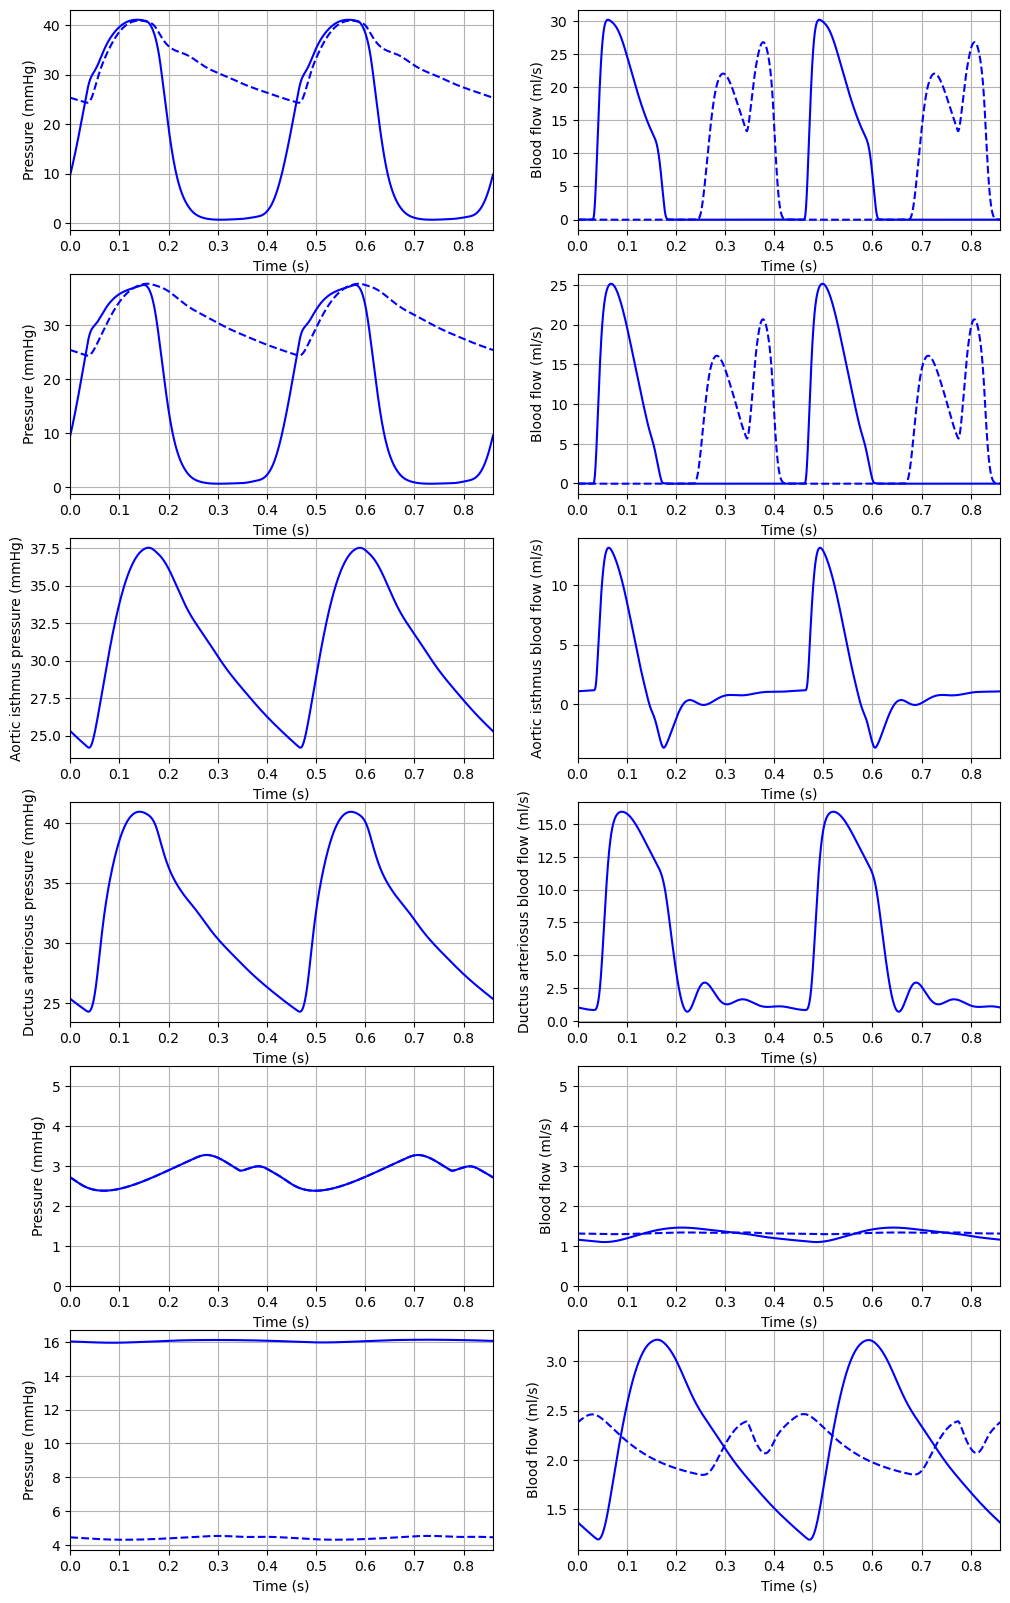

In [ ]:
v_degree_ist = [1]
v_degree_LV = [0.85]
v_degree_da = [1]
v_colors = ['b']

Tc = 0.43
GA = 32 
weight = 10**(0.2508+0.1458*GA-0.0016*GA**2) 

# Run first the healthy case and save parameters
_, f = plt.subplots(ncols = 2, nrows = 6, figsize = (12, 20))
f = f.flatten()

with f_CoA.HiddenPrints():
    tFinal = 25*Tc
    m = solver.model.ModelSolver('FETAL_MODEL_CoA.c')
    m.solve(tFinal = tFinal)

idx = m.t > tFinal - 2*Tc

constants_names = ['Aao','Apv','Ami','Atr','Vwall_lv','Vwall_rv','Amref_lv','Amref_rv','Vwall_la','Vwall_ra','Amref_la','Amref_ra','Amdead_lv','Amdead_rv','Amdead_la','Amdead_ra','Risthm','Bisthm','Cisthm','Listhm','RdAoA','BdAoA','CdAoA','LdAoA','RaAoA','CaAoA','LaAoA','Raa','Caa','Laa','Rpa','Bmpa','Lpa','Cpa','Rda','Bda','Kda','Lda']
default_constants = {element: m.getConstant('Parameters', element) for element in constants_names}

idx = m.t > tFinal - Tc
Ls_lv_healthy = m.getVariable('LV', 'Ls')[idx]
Ls_rv_healthy = m.getVariable('RV', 'Ls')[idx]
healthy_Vcav_Vwall_lv = 1.09287391
healthy_Vcav_Vwall_rv = 1.1546224
CSV = 4.8803759
healthy_r_isthm = 0.2329 
healthy_r_da = 0.2090 

# Run CoA cases
for index in range(len(v_degree_ist)):
    print(index)
    color = v_colors[index]
    degree_ist = v_degree_ist[index]
    index_LV = v_degree_LV[index]
    index_da = v_degree_da[index]

    Vwall_lv = default_constants['Vwall_lv']*index_LV
    Vwall_rv = default_constants['Vwall_rv']*(2-index_LV)
    Amref_lv = default_constants['Amref_lv']*index_LV**(2/3)
    Amref_rv = default_constants['Amref_rv']*(2-index_LV)**(2/3)

    res = optimize.minimize_scalar(function_to_optimise_thicknessLV,args=(index_da, degree_ist, healthy_Vcav_Vwall_lv, Ls_lv_healthy, Ls_rv_healthy, weight, default_constants, Tc, Vwall_lv, Amref_rv, Vwall_rv),bounds=(6, 18), method='bounded')
    Amref_lv = res.x
    print(f"Amref_lv = {Amref_lv}")

    res = optimize.minimize_scalar(function_to_optimise_CSV,args=(index_da, degree_ist, CSV, Ls_lv_healthy, Ls_rv_healthy, weight, default_constants, Tc, Amref_lv, Vwall_lv, Amref_rv),bounds=(1, 3), method='bounded')
    variation = res.x
    Vwall_rv = default_constants['Vwall_rv']*variation
    print(f"Vwall_rv = {Vwall_rv}")

    res = optimize.minimize_scalar(function_to_optimise_thicknessRV,args=(index_da, degree_ist, healthy_Vcav_Vwall_rv, Ls_lv_healthy, Ls_rv_healthy, weight, default_constants, Tc, Amref_lv, Vwall_lv, Vwall_rv),bounds=(18, 40), method='bounded')
    Amref_rv = res.x
    print(f"Amref_rv = {Amref_rv}")

    m = solver.model.ModelSolver('FETAL_MODEL_CoA.c')
    ductus_increase(m,index_da,default_constants)
    aortic_narrowing(m,degree_ist,default_constants)
    m.setConstantOrState0('Parameters', 'Vwall_lv', Vwall_lv)
    m.setConstantOrState0('Parameters', 'Vwall_rv', Vwall_rv)
    m.setConstantOrState0('Parameters', 'Amref_lv', Amref_lv)
    m.setConstantOrState0('Parameters', 'Amref_rv', Amref_rv)   
    m.setConstantOrState0('Parameters', 'Vwall_la', default_constants['Vwall_la']*Vwall_lv/default_constants['Vwall_lv'])
    m.setConstantOrState0('Parameters', 'Vwall_ra', default_constants['Vwall_ra']*Vwall_rv/default_constants['Vwall_rv'])
    m.setConstantOrState0('Parameters', 'Amref_la', default_constants['Amref_la']*Vwall_lv**(2/3)/default_constants['Vwall_lv']**(2/3))
    m.setConstantOrState0('Parameters', 'Amref_ra', default_constants['Amref_ra']*Vwall_rv**(2/3)/default_constants['Vwall_rv']**(2/3))
    m.setConstantOrState0('Parameters', 'Amdead_lv', default_constants['Amdead_lv']*Vwall_lv**(2/3)/default_constants['Vwall_lv']**(2/3))
    m.setConstantOrState0('Parameters', 'Amdead_rv', default_constants['Amdead_rv']*Vwall_rv**(2/3)/default_constants['Vwall_rv']**(2/3)) 
    m.setConstantOrState0('Parameters', 'Amdead_la', default_constants['Amdead_la']*Vwall_lv**(2/3)/default_constants['Vwall_lv']**(2/3))
    m.setConstantOrState0('Parameters', 'Amdead_ra', default_constants['Amdead_ra']*Vwall_rv**(2/3)/default_constants['Vwall_rv']**(2/3)) 
    m.setConstantOrState0('Parameters', 'Aao', default_constants['Aao']*Vwall_lv**(2/3)/default_constants['Vwall_lv']**(2/3))
    m.setConstantOrState0('Parameters', 'Ami', default_constants['Ami']*Vwall_lv**(2/3)/default_constants['Vwall_lv']**(2/3))
    m.setConstantOrState0('Parameters', 'Apv', default_constants['Apv']*Vwall_rv**(2/3)/default_constants['Vwall_rv']**(2/3))
    m.setConstantOrState0('Parameters', 'Atr', default_constants['Atr']*Vwall_rv**(2/3)/default_constants['Vwall_rv']**(2/3))        
    ventricular_disproportion_vasculature(m,Vwall_lv**(2/3)/default_constants['Vwall_lv']**(2/3),Vwall_rv**(2/3)/default_constants['Vwall_rv']**(2/3),default_constants)

    with f_CoA.HiddenPrints():
        m.solve(tFinal = tFinal)

    default_plot(f,m,index+1,2,Tc,tFinal,color)

    r_isthm = healthy_r_isthm*degree_ist
    print(r_isthm)
    r_da = healthy_r_da*index_da

    idx = m.t > tFinal - Tc
    #Ls_lv_min = np.min(m.getVariable('LV', 'Ls')[idx])
    #Ls_lv_max = np.max(m.getVariable('LV', 'Ls')[idx])
    #Ls_rv_min = np.min(m.getVariable('RV', 'Ls')[idx])
    #Ls_rv_max = np.max(m.getVariable('RV', 'Ls')[idx])
    CSV_now = np.trapz(m.getVariable('LV', 'Qo')[idx], m.t[idx]) + np.trapz(m.getVariable('RV', 'Qo')[idx], m.t[idx])
    Vcav_rv = np.max(m.getVariable('RV', 'Vcav')[idx])
    Vcav_Vwall_rv = Vcav_rv/Vwall_rv    
    Vcav_lv = np.max(m.getVariable('LV', 'Vcav')[idx])
    Vcav_Vwall_lv = Vcav_lv/Vwall_lv 
    print(f"v_ist = {np.max(m.getVariable('AI_RCL','Qo')[idx]/(np.pi*r_isthm**2))}")
    print(f"CSV = {CSV_now}")
    print(f"Vcav_Vwall_lv = {Vcav_Vwall_lv}")
    print(f"Vcav_Vwall_rv = {Vcav_Vwall_rv}")

    print(f"EDV ratio = {Vcav_lv/Vcav_rv}")

    print(f"Amref_rv = {Amref_rv}")
    print(f"Amref_lv = {Amref_lv}")
    print(f"Vwall_rv = {Vwall_rv}")
    print(f"Vwall_lv = {Vwall_lv}")
    

    #m.saveResults(f"IST{round(degree_ist*100)}_LV{round(index_LV*100)}_DA{round(index_da*100)}.npz", degree_ist = degree_ist, degree_da = index_da, degree_LV = index_LV)
    #m.saveResults(f"Results_figure/IST{round(degree_ist*100)}_LV{round(index_LV*100)}_DA{round(index_da*100)}.npz", degree_ist = degree_ist, degree_da = index_da, degree_LV = index_LV)
